<a href="https://colab.research.google.com/github/Thilina93Gunasekara/it5437_assignment_02_258774L/blob/main/IT5437_A02_Q2_Earring_Size.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT5437 Assignment 02 - Question 2: Physical Size of the Earrings
**258774L - M.L.D.T.D.U. GUNASEKARA**

Uses the **pinhole camera model** and **thin lens equation** to determine
the real-world size of the earrings from the image.

**Given:**
- Focal length: f = 8 mm  
- Pixel size: p = 2.2 µm  
- Image distance: v = 720 mm


Saving earrings.jpg to earrings (1).jpg
Image loaded: earrings (1).jpg  |  size: 1024 x 1024 pixels

Step 1 — Focal length in pixels:
  f_px = 8.0 / 0.0022 = 3636.3636 px

Step 2 — Object distance via thin lens equation:
  1/f = 1/v + 1/u  =>  u = f*v/(v-f)
  u = (8.0 x 720.0) / (720.0 - 8.0)
  u = 8.089888 mm

Step 3 — Scale factor:
  scale = pixel_size_mm * u / f_mm
  scale = 0.0022 * 8.089888 / 8.0
  scale = 0.00222472 mm/pixel

  RESULTS — Physical Size of Each Earring

  Left earring:
    Bounding box (pixels) : 382 w x 400 h
    Avg diameter (pixels) : 391.0 px
    Width  (mm)           : 0.8498 mm
    Height (mm)           : 0.8899 mm
    Avg diameter (mm)     : 0.8699 mm

  Right earring:
    Bounding box (pixels) : 382 w x 400 h
    Avg diameter (pixels) : 391.0 px
    Width  (mm)           : 0.8498 mm
    Height (mm)           : 0.8899 mm
    Avg diameter (mm)     : 0.8699 mm


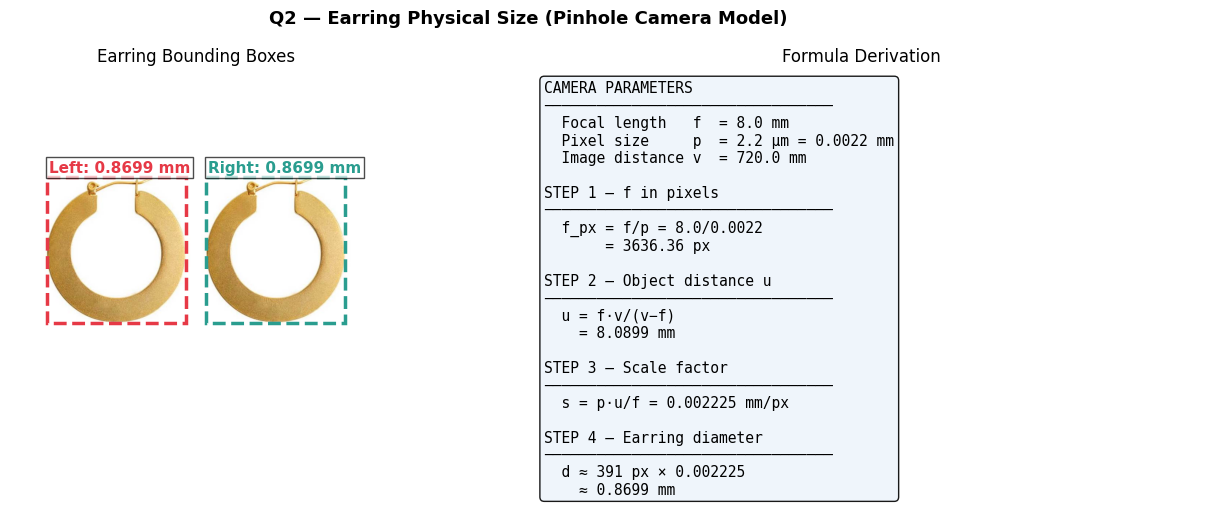


Figure saved as q2_result.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# IT5437 Assignment 02 — Question 2
# Physical Size of the Earrings using Pinhole Camera Model
# ═══════════════════════════════════════════════════════════════════════════════

# Step 0: Install / import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
from io import BytesIO

# Step 1: Upload the earrings image
# Run this cell first. A file chooser will appear — upload earrings.jpg
from google.colab import files
uploaded = files.upload()                         # select earrings.jpg
img_name = list(uploaded.keys())[0]
img = Image.open(img_name).convert('RGB')
img_np = np.array(img)
W, H = img.size
print(f"Image loaded: {img_name}  |  size: {W} x {H} pixels")

# Step 2: Given camera parameters
f_mm          = 8.0          # focal length in mm
pixel_size_um = 2.2          # pixel size in micrometres
pixel_size_mm = pixel_size_um * 1e-3   # 0.0022 mm/pixel
v_mm          = 720.0        # image distance (lens to sensor) in mm

# Step 3: Convert focal length to pixels
f_px = f_mm / pixel_size_mm
print(f"\nStep 1 — Focal length in pixels:")
print(f"  f_px = {f_mm} / {pixel_size_mm} = {f_px:.4f} px")

# Step 4: Find object distance using thin lens equation
u_mm = (f_mm * v_mm) / (v_mm - f_mm)
print(f"\nStep 2 — Object distance via thin lens equation:")
print(f"  1/f = 1/v + 1/u  =>  u = f*v/(v-f)")
print(f"  u = ({f_mm} x {v_mm}) / ({v_mm} - {f_mm})")
print(f"  u = {u_mm:.6f} mm")

# Step 5: Compute scale factor

scale_mm_per_px = pixel_size_mm * u_mm / f_mm
print(f"\nStep 3 — Scale factor:")
print(f"  scale = pixel_size_mm * u / f_mm")
print(f"  scale = {pixel_size_mm} * {u_mm:.6f} / {f_mm}")
print(f"  scale = {scale_mm_per_px:.8f} mm/pixel")

# Step 6: Measure earring size in pixels
# Detect earring pixels by thresholding white background
# White background: R > 230, G > 230, B > 230
bg_mask      = (img_np[:,:,0] > 230) & \
               (img_np[:,:,1] > 230) & \
               (img_np[:,:,2] > 230)
earring_mask = ~bg_mask

results = []
half_W = W // 2

for side, col_start, col_end in [('Left', 0, half_W), ('Right', half_W, W)]:
    half = earring_mask[:, col_start:col_end]
    rows = np.any(half, axis=1)
    cols = np.any(half, axis=0)

    if rows.sum() == 0 or cols.sum() == 0:
        print(f"  WARNING: No earring pixels found in {side} half!")
        continue

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    h_px = rmax - rmin
    w_px = cmax - cmin
    d_px = (h_px + w_px) / 2.0    # average as proxy for circular diameter

    results.append({
        'side'   : side,
        'rmin'   : rmin, 'rmax': rmax,
        'cmin'   : cmin + col_start, 'cmax': cmax + col_start,
        'h_px'   : h_px,   'w_px'  : w_px,   'd_px'  : d_px,
        'h_mm'   : h_px   * scale_mm_per_px,
        'w_mm'   : w_px   * scale_mm_per_px,
        'd_mm'   : d_px   * scale_mm_per_px,
    })

# Step 7: Print results
print("\n" + "="*55)
print("  RESULTS — Physical Size of Each Earring")
print("="*55)
for r in results:
    print(f"\n  {r['side']} earring:")
    print(f"    Bounding box (pixels) : {r['w_px']} w x {r['h_px']} h")
    print(f"    Avg diameter (pixels) : {r['d_px']:.1f} px")
    print(f"    Width  (mm)           : {r['w_mm']:.4f} mm")
    print(f"    Height (mm)           : {r['h_mm']:.4f} mm")
    print(f"    Avg diameter (mm)     : {r['d_mm']:.4f} mm")
print("="*55)

# Step 8: Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e63946', '#2a9d8f']

# Left plot: annotated earring image
ax = axes[0]
ax.imshow(img_np)
for r, c in zip(results, colors):
    rect = patches.Rectangle(
        (r['cmin'], r['rmin']),
        r['cmax'] - r['cmin'], r['rmax'] - r['rmin'],
        linewidth=2.5, edgecolor=c, facecolor='none', linestyle='--'
    )
    ax.add_patch(rect)
    ax.text(
        r['cmin'] + 5, r['rmin'] - 15,
        f"{r['side']}: {r['d_mm']:.4f} mm",
        color=c, fontsize=11, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.7, pad=2)
    )
ax.set_title('Earring Bounding Boxes', fontsize=12)
ax.axis('off')

# Right plot: step-by-step formula summary
ax2 = axes[1]
ax2.axis('off')
summary = (
    f"CAMERA PARAMETERS\n"
    f"─────────────────────────────────\n"
    f"  Focal length   f  = {f_mm} mm\n"
    f"  Pixel size     p  = {pixel_size_um} µm = {pixel_size_mm} mm\n"
    f"  Image distance v  = {v_mm} mm\n\n"
    f"STEP 1 — f in pixels\n"
    f"─────────────────────────────────\n"
    f"  f_px = f/p = {f_mm}/{pixel_size_mm}\n"
    f"       = {f_px:.2f} px\n\n"
    f"STEP 2 — Object distance u\n"
    f"─────────────────────────────────\n"
    f"  u = f·v/(v−f)\n"
    f"    = {u_mm:.4f} mm\n\n"
    f"STEP 3 — Scale factor\n"
    f"─────────────────────────────────\n"
    f"  s = p·u/f = {scale_mm_per_px:.6f} mm/px\n\n"
    f"STEP 4 — Earring diameter\n"
    f"─────────────────────────────────\n"
    f"  d ≈ {results[0]['d_px']:.0f} px × {scale_mm_per_px:.6f}\n"
    f"    ≈ {results[0]['d_mm']:.4f} mm"
)
ax2.text(0.05, 0.97, summary, transform=ax2.transAxes,
         fontsize=10.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#eef4fb', alpha=0.9))
ax2.set_title('Formula Derivation', fontsize=12)

plt.suptitle('Q2 — Earring Physical Size (Pinhole Camera Model)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q2_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigure saved as q2_result.png")
